### Analysis description
Here we aim at drawing a pycortex flatmaps, create static webgl, and plot inflated brain maps.<br/>

In [1]:
# Stop warnings
import warnings
warnings.filterwarnings("ignore")

# Debug import 
import ipdb
deb = ipdb.set_trace

# General imports
import os
import numpy as np
import sys
import cortex
import re, time, glob
import matplotlib.pyplot as plt

# Personal imports
sys.path.append("{}/../../../../../analysis_code/utils".format(os.getcwd()))
from pycortex_utils import draw_cortex, set_pycortex_config_file, load_surface_pycortex, create_colormap
from settings_utils import load_settings


In [2]:
# Manually defined parameters
subject = 'sub-01'
pycortex_subject = subject
eye_descriptions = ['FE', 'AE'] # Left / Right
prf_task_names = ['BarsBarsRingsWedgesLeftEye', 'BarsBarsRingsWedgesRightEye']
pycortex_subject = subject
project_dir = 'amblyo7T_prf'
main_dir = '/home/mszinte/disks/meso_S/data'
format_ = 'fsnative'
avg_method = 'concat'
rois_method_format = 'rois-group-mmp'
overlay_fn = f"overlays_{rois_method_format}_poster.svg"

In [3]:
# Load settings
base_dir = os.path.abspath(os.path.join(os.getcwd(), "../../../../../"))
settings_path = os.path.join(base_dir, project_dir, "settings.yml")
prf_settings_path = os.path.join(base_dir, project_dir, "prf-analysis.yml")
figure_settings_path = os.path.join(base_dir, project_dir, "figure-settings.yml")
settings = load_settings([settings_path, prf_settings_path, figure_settings_path])
analysis_info = settings[0]
if subject == 'sub-170k': formats = ['170k']
else: formats = analysis_info['formats']
preproc_prep = analysis_info['preproc_prep']
filtering = analysis_info['filtering']
normalization = analysis_info['normalization']
rois_methods = analysis_info['rois_methods']
pycortex_subject_template = analysis_info['pycortex_subject_template']
maps_names_pcm = analysis_info['maps_names_pcm']
maps_names_css_stats = analysis_info['maps_names_css_stats']
maps_names_css = analysis_info['maps_names_css']

# plot scales
save_svg = 'n'
cmap_polar, cmap_uni, cmap_ecc_size, cmap_pcm = 'hsv', 'Reds', 'Spectral', 'Spectral_r'
col_offset = 1.0/14.0
cmap_steps = 255

rsq_scale = analysis_info['flatmap_rsq_scale']
ecc_scale = [0,6]#analysis_info['flatmap_ecc_scale']
size_scale = [0, 2] #analysis_info['flatmap_size_scale']
n_scale = analysis_info['flatmap_n_scale']
pcm_scale = [0,20]#analysis_info['flatmap_pcm_scale']
alpha_range = analysis_info["flatmap_alpha_range"]


# Set pycortex db and colormaps
cortex_dir = "{}/{}/derivatives/pp_data/cortex".format(main_dir, project_dir)
set_pycortex_config_file(cortex_dir)
print(cortex_dir)

# Define/create colormap
rois_colors = analysis_info['rois_colors']
colormap_name = 'rois_colors'
colormap_dict = {key: tuple(value) for key, value in rois_colors.items()}
create_colormap(cortex_dir=cortex_dir, 
                colormap_name=colormap_name, 
                colormap_dict=colormap_dict,
                recreate=True)

/home/mszinte/disks/meso_S/data/amblyo7T_prf/derivatives/pp_data/cortex
Saving new colormap: /home/mszinte/disks/meso_S/data/amblyo7T_prf/derivatives/pp_data/cortex/colormaps/rois_colors.png


In [4]:
# Create ROI flatmaps
# Define directories and fn
rois_dir = "{}/{}/derivatives/pp_data/{}/{}/rois".format(main_dir, project_dir, subject, format_)
flatmaps_dir = '{}/pycortex/flatmaps_rois'.format(rois_dir)
datasets_dir = '{}/pycortex/datasets_rois'.format(rois_dir)
roi_fn_L = '{}/{}_hemi-L_{}_{}_{}_{}.func.gii'.format(rois_dir, subject, 
                                                      preproc_prep, filtering, 
                                                      normalization, rois_method_format)
roi_fn_R = '{}/{}_hemi-R_{}_{}_{}_{}.func.gii'.format(rois_dir, subject,
                                                      preproc_prep, filtering, 
                                                      normalization, rois_method_format)
results = load_surface_pycortex(L_fn=roi_fn_L, R_fn=roi_fn_R)
roi_mat = results['data_concat']

# Define CSS R2 / Size / CM
prf_dir = "{}/{}/derivatives/pp_data/{}/{}/prf".format(
                main_dir, project_dir, subject, format_)
prf_deriv_dir = "{}/prf_derivatives".format(prf_dir)

In [5]:
volumes = {}
for prf_task_name, eye_description in zip(prf_task_names, eye_descriptions):
    deriv_fns_L = sorted(
        glob.glob('{}/{}_task-{}_hemi-L_{}_{}_{}_{}_prf-css_deriv.func.gii'.format(
            prf_deriv_dir, subject, prf_task_name, preproc_prep, filtering, normalization, avg_method)) +
        glob.glob('{}/{}_task-{}_run-*_hemi-L_{}_{}_{}_{}_prf-css_deriv.func.gii'.format(
            prf_deriv_dir, subject, prf_task_name, preproc_prep, filtering, normalization, avg_method))
    )
    # Loading data
    deriv_fn_L = deriv_fns_L[0]
    deriv_fn_R = deriv_fn_L.replace('hemi-L', 'hemi-R')
    stats_fn_L = deriv_fn_L.replace('prf-css_deriv', 'prf-css_stats')
    stats_fn_R = deriv_fn_R.replace('prf-css_deriv', 'prf-css_stats')
    pcm_fn_L   = deriv_fn_L.replace('prf-css_deriv', 'prf-css_pcm').replace(
                     f'_{avg_method}_', f'_{avg_method}_{rois_method_format}_')
    pcm_fn_R   = deriv_fn_R.replace('prf-css_deriv', 'prf-css_pcm').replace(
                     f'_{avg_method}_', f'_{avg_method}_{rois_method_format}_')
    
    deriv_mat = load_surface_pycortex(L_fn=deriv_fn_L, R_fn=deriv_fn_R)['data_concat']
    stats_mat = load_surface_pycortex(L_fn=stats_fn_L, R_fn=stats_fn_R)['data_concat']
    pcm_mat   = load_surface_pycortex(L_fn=pcm_fn_L,   R_fn=pcm_fn_R  )['data_concat']
    # Threshold data
    for idx, col_name in enumerate(maps_names_css + maps_names_css_stats + maps_names_pcm):
            exec("{}_idx = idx".format(col_name))
    rsq_idx2use = prf_rsq_idx
    rsq_description = f'{eye_description} CSS pRF R2'
    rsq_cbar_label = 'pRF R2'
    
    # Combine mat
    all_deriv_mat = np.concatenate((deriv_mat, stats_mat, pcm_mat))
    
    # Threshold mat
    all_deriv_mat_th = all_deriv_mat
    amp_down = all_deriv_mat_th[amplitude_idx,...] > 0
    rsq_down = all_deriv_mat_th[rsq_idx2use,...] >= 0.05
    size_th_down = all_deriv_mat_th[prf_size_idx,...] >= analysis_info['size_th'][0]
    size_th_up = all_deriv_mat_th[prf_size_idx,...] <= analysis_info['size_th'][1]
    ecc_th_down = all_deriv_mat_th[prf_ecc_idx,...] >= analysis_info['ecc_th'][0]
    ecc_th_up = all_deriv_mat_th[prf_ecc_idx,...] <= analysis_info['ecc_th'][1]
    n_th_down = all_deriv_mat_th[prf_n_idx,...] >= analysis_info['n_th'][0]
    n_th_up = all_deriv_mat_th[prf_n_idx,...] <= analysis_info['n_th'][1]
    if analysis_info['stats_th'] == 0.05: stats_th_down = all_deriv_mat_th[corr_pvalue_5pt_idx,...] <= 0.05
    elif analysis_info['stats_th'] == 0.01: stats_th_down = all_deriv_mat_th[corr_pvalue_1pt_idx,...] <= 0.01
    all_th = np.array((amp_down, rsq_down, size_th_down, size_th_up,
                       ecc_th_down, ecc_th_up, n_th_down, n_th_up, stats_th_down))
    all_deriv_mat[rsq_idx2use, np.logical_and.reduce(all_th)==False] = 0
    
    # Create flatmaps
    print('Creating flatmaps...')
    maps_names = []
    
    # R-square and alpha (loo or not)
    rsq_data = all_deriv_mat[rsq_idx2use,...]
    alpha = rsq_data
    alpha = (alpha - alpha_range[0]) / (alpha_range[1] - alpha_range[0])
    alpha[alpha>1] = 1
    
    # param_rsq = {'data': rsq_data,
    #              'cmap': cmap_uni,
    #              'alpha': alpha,
    #              'vmin': rsq_scale[0],
    #              'vmax': rsq_scale[1],
    #              'cbar': 'discrete',
    #              'cortex_type': 'VertexRGB',
    #              'description': rsq_description,
    #              'curv_brightness': 0.8,
    #              'curv_contrast': 0.3,
    #              'add_roi': save_svg,
    #              'cbar_label': rsq_cbar_label,
    #              'overlay_fn': overlay_fn,
    #              'with_labels': True}
    # maps_names.append('rsq')
    
    # Size
    size_data = all_deriv_mat[prf_size_idx,...]
    param_size = {'data': size_data,
                  'cmap': cmap_ecc_size,
                  'alpha': alpha,
                  'vmin': size_scale[0],
                  'vmax': size_scale[1],
                  'cbar': 'discrete',
                  'cortex_type': 'VertexRGB',
                  'description': f'{eye_description} CSS pRF size',
                  'curv_brightness': 0.8,
                  'curv_contrast': 0.3,
                  'add_roi': False,
                  'cbar_label': 'pRF size (dva)',
                  'overlay_fn': overlay_fn,
                  'with_labels': True}
    maps_names.append('size')

    # Eccentricity
    ecc_data = all_deriv_mat[prf_ecc_idx,...]
    param_ecc = {'data': ecc_data,
                 'cmap': cmap_ecc_size,
                 'alpha': alpha,
                 'vmin': ecc_scale[0],
                 'vmax': ecc_scale[1],
                 'cbar': 'ecc',
                 'cortex_type': 'VertexRGB',
                 'description': f'{eye_description} CSS pRF eccentricity',
                 'curv_brightness': 1,
                 'curv_contrast': 0.1,
                 'add_roi': save_svg,
                 'overlay_fn': overlay_fn,
                 'with_labels': True}
    maps_names.append('ecc')

    
    # pcm
    pcm_data = all_deriv_mat[pcm_median_idx,...]
    alpha_pcm = np.copy(alpha)
    alpha_pcm[np.isnan(pcm_data)] = 0
    param_pcm = {'data': pcm_data,
                 'cmap': cmap_pcm,
                 'alpha': alpha_pcm,
                 'vmin': pcm_scale[0],
                 'vmax': pcm_scale[1],
                 'cbar': 'discrete',
                 'cortex_type': 'VertexRGB',
                 'description': f'{eye_description} CSS pRF CM',
                 'curv_brightness': 0.8,
                 'curv_contrast': 0.3,
                 'add_roi': False,
                 'cbar_label': 'pRF CM (mm/dva)',
                 'overlay_fn': overlay_fn,
                 'with_labels': True}
    maps_names.append('pcm')
    # draw flatmaps
    
    for maps_name in maps_names:
    
        # create flatmap
        roi_name = 'prf_{}'.format(maps_name)
        roi_param = {'subject': pycortex_subject,
                     'xfmname': None,
                     'roi_name': roi_name}
        print(f'{eye_description} {roi_name}')
        exec('param_{}.update(roi_param)'.format(maps_name))
        exec('volume_{maps_name} = draw_cortex(**param_{maps_name})'.format(maps_name=maps_name))
        flatmap_fn = '{}/{}_{}.pdf'.format(os.getcwd(), eye_description, maps_name)
        exec("plt.savefig('{}')".format(flatmap_fn))
        print(f"Saved flatmap: {flatmap_fn}")
        plt.close()
    
        # save flatmap as dataset
        exec('vol_description = param_{}["description"]'.format(maps_name))
        exec('volume = volume_{}'.format(maps_name))
        volumes.update({vol_description: volume})

Creating flatmaps...
FE prf_size
Color map Spectral is already registered.
Unable to init server: Could not connect: Connection refused
Failed to get connection
** (inkscape:767930): CRITICAL **: 15:16:15.925: dbus_g_proxy_new_for_name: assertion 'connection != NULL' failed
** (inkscape:767930): CRITICAL **: 15:16:15.925: dbus_g_proxy_call: assertion 'DBUS_IS_G_PROXY (proxy)' failed
** (inkscape:767930): CRITICAL **: 15:16:15.925: dbus_g_connection_register_g_object: assertion 'connection != NULL' failed
** (inkscape:767930): WARNING **: 15:16:16.191: Fonts dir '/usr/share/inkscape/fonts' does not exist and will be ignored.
** (inkscape:767930): WARNING **: 15:16:16.191: Fonts dir '/home/mszinte/.config/inkscape/fonts' does not exist and will be ignored.
Background RRGGBBAA: ffffff00
Area 0:0:2316.19:1024 exported to 2316 x 1024 pixels (96 dpi)
Saved flatmap: /home/mszinte/disks/meso_H/projects/pRF_analysis/amblyo7T_prf/postproc/prf/postfit/dev/FE_size.pdf
FE prf_ecc
Color map Spectral

Creating flatmaps...
Unable to init server: Could not connect: Connection refused
Failed to get connection
** (inkscape:768478): CRITICAL **: 15:18:02.558: dbus_g_proxy_new_for_name: assertion 'connection != NULL' failed
** (inkscape:768478): CRITICAL **: 15:18:02.558: dbus_g_proxy_call: assertion 'DBUS_IS_G_PROXY (proxy)' failed
** (inkscape:768478): CRITICAL **: 15:18:02.558: dbus_g_connection_register_g_object: assertion 'connection != NULL' failed
** (inkscape:768478): WARNING **: 15:18:02.818: Fonts dir '/usr/share/inkscape/fonts' does not exist and will be ignored.
** (inkscape:768478): WARNING **: 15:18:02.818: Fonts dir '/home/mszinte/.config/inkscape/fonts' does not exist and will be ignored.
Background RRGGBBAA: ffffff00
Area 0:0:2316.19:1024 exported to 2316 x 1024 pixels (96 dpi)


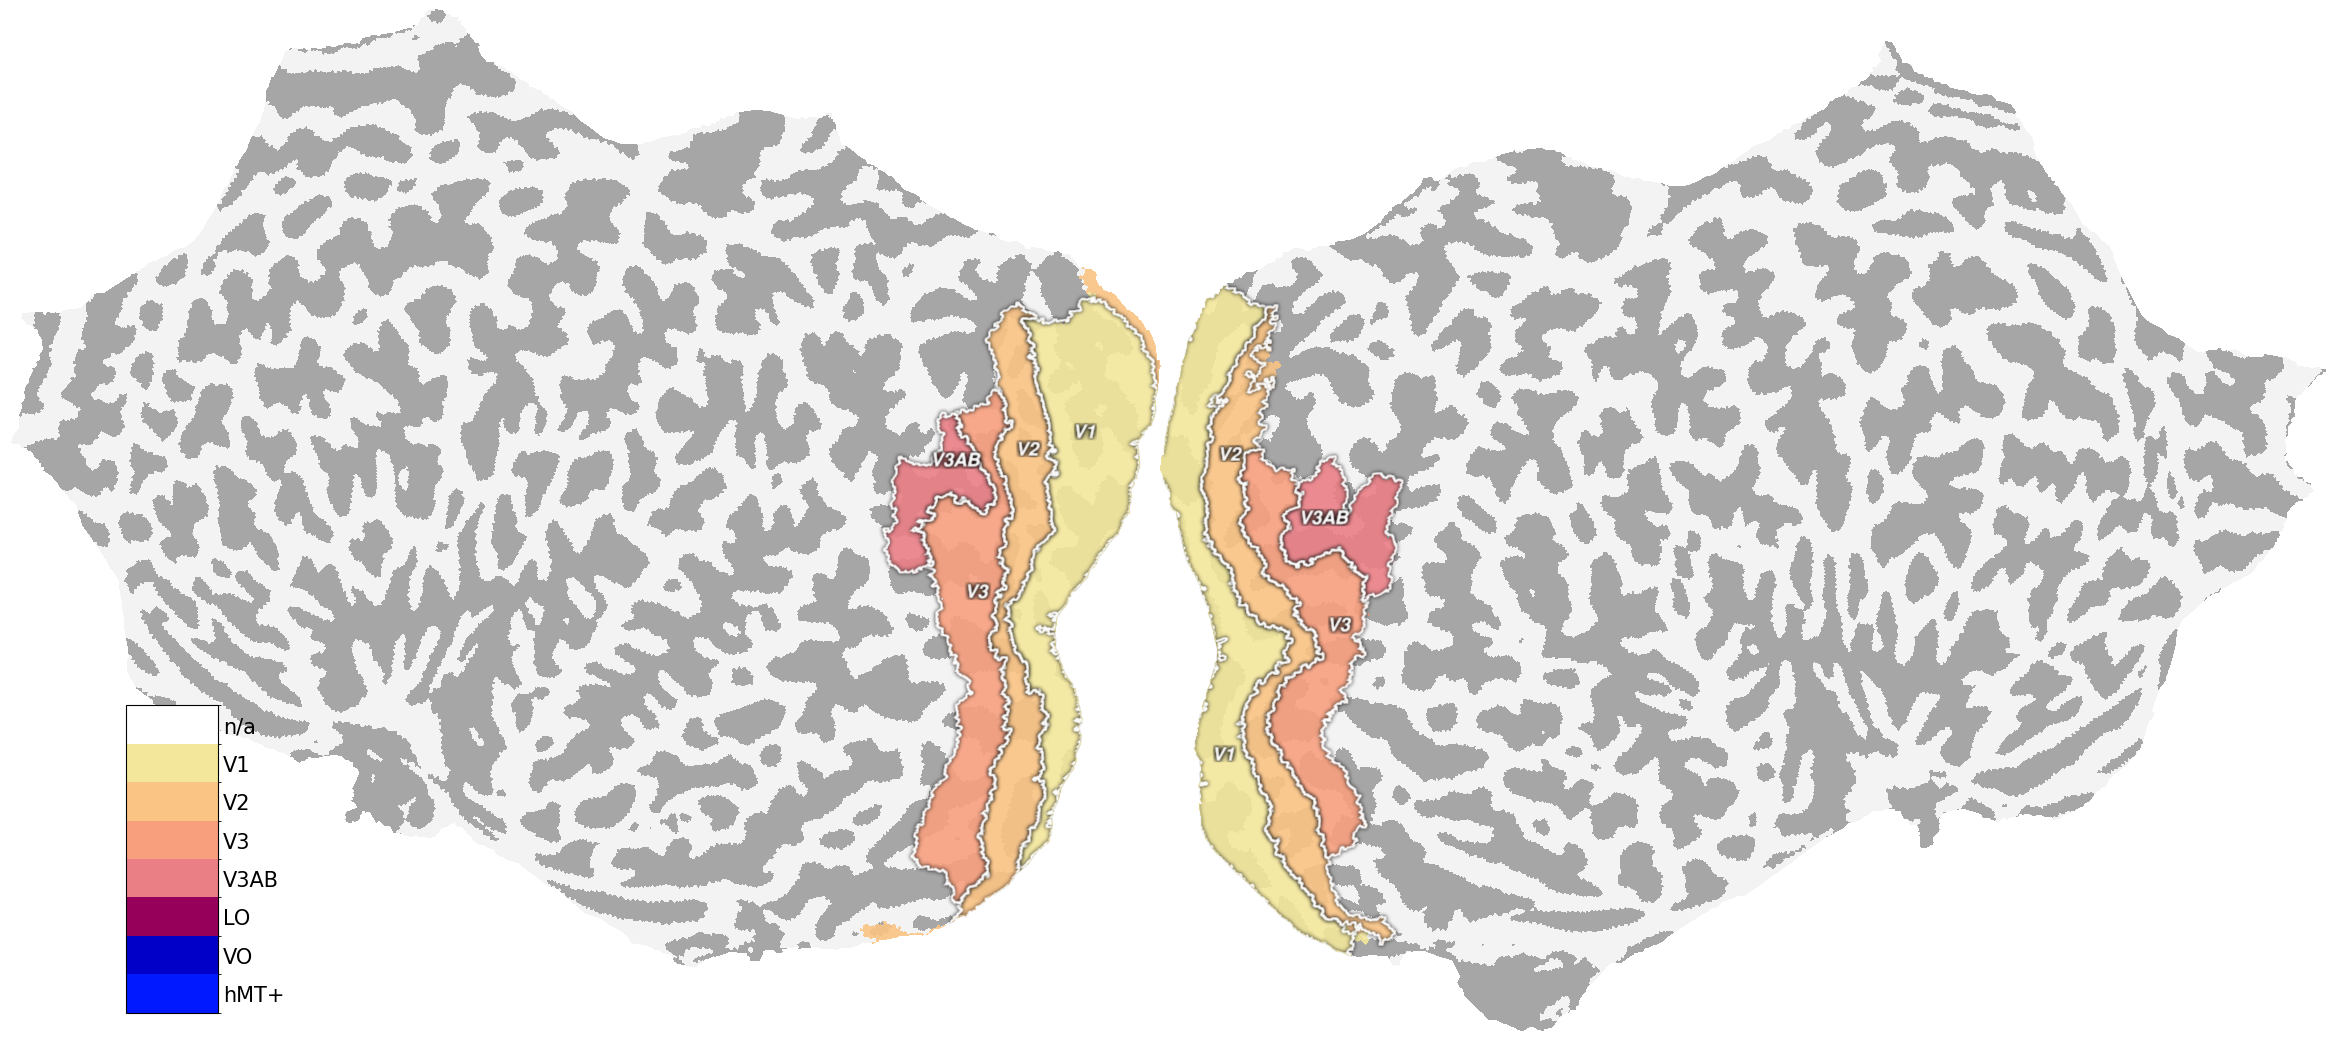

In [6]:
rois_opacity = 0.9
alpha_mat = roi_mat*0+rois_opacity
alpha_mat[roi_mat==0]=0

# Show only V1/V2/V3/V3AB
alpha_mat[roi_mat==5]=0
alpha_mat[roi_mat==6]=0
alpha_mat[roi_mat==7]=0
print('Creating flatmaps...')

# Rois
roi_name = 'rois'
param_rois = {'subject': pycortex_subject,
              'data': roi_mat, 
              'cmap': colormap_name,
              'alpha': alpha_mat,
              'cbar': 'discrete_personalized', 
              'vmin': 0,
              'vmax': len(colormap_dict),
              'cmap_steps': len(colormap_dict),
              'cmap_dict': colormap_dict,
              'cortex_type': 'VertexRGB',
              'description': 'ROIs',
              'curv_brightness': 0.8, 
              'overlay_fn': overlay_fn,
              'curv_contrast': 0.3,
              'add_roi': 'n',
              'with_labels': True,
              'roi_name': roi_name}
              
# Draw flatmaps
volume_roi = draw_cortex(**param_rois)
plt.savefig('{}/rois_flat.pdf'.format(os.getcwd()))
volumes.update({'ROI': volume_roi})

In [7]:
volumes

{'FE CSS pRF size': <RGB vertex data for (sub-01)>,
 'FE CSS pRF eccentricity': <RGB vertex data for (sub-01)>,
 'FE CSS pRF CM': <RGB vertex data for (sub-01)>,
 'AE CSS pRF size': <RGB vertex data for (sub-01)>,
 'AE CSS pRF eccentricity': <RGB vertex data for (sub-01)>,
 'AE CSS pRF CM': <RGB vertex data for (sub-01)>,
 'ROI': <RGB vertex data for (sub-01)>}

In [9]:
# Webgl for inflated brain pictures
port_num = 25976 # open on invibe server
print("Command to type on local terminal...")
print("ssh -Y -fN -L localhost:{}:localhost:{} admin@invibe.nohost.me".format(port_num,port_num))
print("Go to (in 5 s...): http://localhost:{}/".format(port_num))
exec('handle = cortex.webgl.show(data=volumes,recache = False, port=port_num, title=subject, labels_visible=[True])')

Command to type on local terminal...
ssh -Y -fN -L localhost:25976:localhost:25976 admin@invibe.nohost.me
Go to (in 5 s...): http://localhost:25976/
Started server on port 25976


In [20]:
# general settings
handle.setData(['ROI'])
set1 = {'camera.azimuth':225,
        'camera.altitude':93,
        'camera.radius':324,
        'surface.{subject}.unfold':0,
        'surface.{subject}.pivot':33,
        'surface.{subject}.left':True,
        'surface.{subject}.right':False,
        'surface.{subject}.depth':0.5,
        'surface.{subject}.specularity':0.2,
        'surface.{subject}.layers':4,
        'surface.{subject}.dither':False,
        'surface.{subject}.colorbar':False,
        'surface.{subject}.sampler':'nearest',
        'surface.{subject}.curvature.brightness':0.2,
        'surface.{subject}.curvature.contrast':0.2,
        'surface.{subject}.curvature.smoothness':0}
handle._set_view(**set1)
time.sleep(5)
handle.getImage('{}/rois_pial.png'.format(os.getcwd()),size = (3000, 3000))

[{}]

In [21]:
set2 = {'camera.azimuth':225,
        'camera.altitude':93,
        'camera.radius':324,
        'surface.{subject}.unfold':0.5,
        'surface.{subject}.pivot':33,
        'surface.{subject}.left':True,
        'surface.{subject}.right':False,
        'surface.{subject}.depth':0.5,
        'surface.{subject}.specularity':0.2,
        'surface.{subject}.layers':4,
        'surface.{subject}.dither':False,
        'surface.{subject}.colorbar':False,
        'surface.{subject}.sampler':'nearest',
        'surface.{subject}.curvature.brightness':0.2,
        'surface.{subject}.curvature.contrast':0.2,
        'surface.{subject}.curvature.smoothness':0}
handle._set_view(**set2)
time.sleep(5)
handle.getImage('{}/rois_inflated.png'.format(os.getcwd()),size = (3000, 3000))

[{}]

In [23]:
handle.setData(['FE CSS pRF eccentricity'])
time.sleep(5)
handle.getImage('{}/FE_ecc_inflated.png'.format(os.getcwd()),size = (3000, 3000))

[{}]

In [24]:
handle.setData(['AE CSS pRF eccentricity'])
time.sleep(5)
handle.getImage('{}/AE_ecc_inflated.png'.format(os.getcwd()),size = (3000, 3000))

[{}]

In [25]:
handle.setData(['FE CSS pRF size'])
time.sleep(5)
handle.getImage('{}/FE_size_inflated.png'.format(os.getcwd()),size = (3000, 3000))

[{}]

In [26]:
handle.setData(['AE CSS pRF size'])
time.sleep(5)
handle.getImage('{}/AE_size_inflated.png'.format(os.getcwd()),size = (3000, 3000))

[{}]

In [27]:
handle.setData(['FE CSS pRF CM'])
time.sleep(5)
handle.getImage('{}/FE_CM_inflated.png'.format(os.getcwd()),size = (3000, 3000))

[{}]

In [28]:
handle.setData(['AE CSS pRF CM'])
time.sleep(5)
handle.getImage('{}/AE_CM_inflated.png'.format(os.getcwd()),size = (3000, 3000))

[{}]